# Детекция мошеннических транзакций (Fraud Detection)

Классификация мошеннических банковских операций на сильно несбалансированных данных.

**Датасет:** Credit Card Fraud Detection (ULB Machine Learning Group), Kaggle — `mlg-ulb/creditcardfraud`
284 807 транзакций, 492 мошеннических (0.172%), признаки V1–V28 (PCA) + Time, Amount.

**Цель:** построить и оценить модель, делая упор на правильные метрики (PR-AUC) и выбор порога.

**Ключевые методические решения:**
- Главная метрика — **PR-AUC** (из-за дисбаланса).
- Балансировка (SMOTE / веса) применяется **только к train** — утечка данных в противном случае.
- Порог решения выбирается под целевой recall.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

RND = 23
sns.set_style('whitegrid')

In [3]:
# загрузка
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip
import pandas as pd
df = pd.read_csv('creditcard.csv')
print(df.shape, '| фрод:', df['Class'].sum())

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 125MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
(284807, 31) | фрод: 492


**EDA**

In [4]:
# базовая информация
print(df.info())
print("\nПропуски:", df.isna().sum().sum())
print("Дубликаты:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df = df.drop_duplicates()

Class
0    283253
1       473
Name: count, dtype: int64

Доля фрода: 0.167%  (дисбаланс ~1:598)


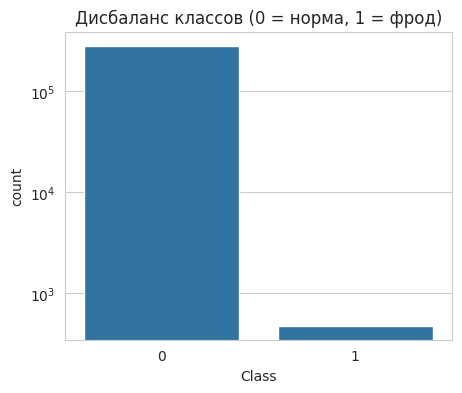

In [6]:
# визуализация дисбаланса
counts = df['Class'].value_counts()
print(counts)
print(f'\nДоля фрода: {df["Class"].mean()*100:.3f}%  (дисбаланс ~1:{int(counts[0]/counts[1])})')

plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df)
plt.title('Дисбаланс классов (0 = норма, 1 = фрод)')
plt.yscale('log')  # лог-шкала
plt.show()

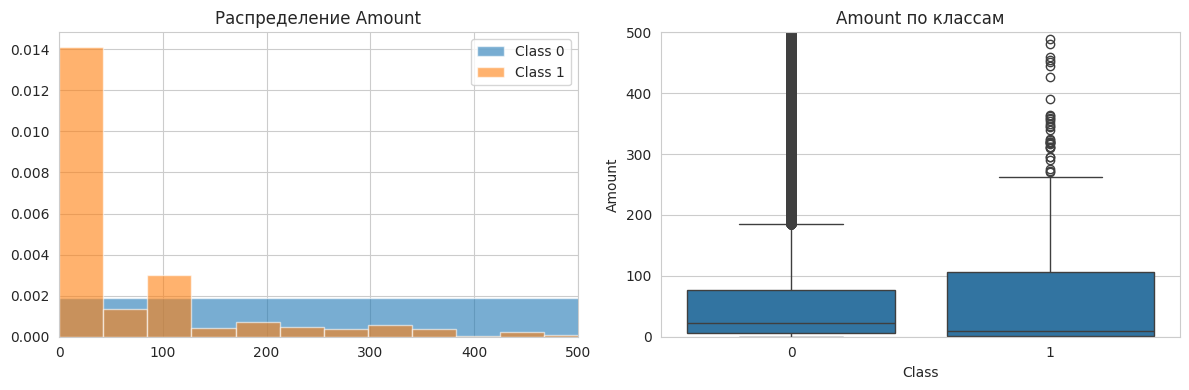

In [7]:
# распределение суммы транзакции по классам
fig, ax = plt.subplots(1,2, figsize=(12,4))
for c in [0,1]:
    ax[0].hist(df[df['Class']==c]['Amount'], bins=50, alpha=0.6,
               label=f'Class {c}', density=True)
ax[0].set_xlim(0,500); ax[0].set_title('Распределение Amount'); ax[0].legend()

sns.boxplot(x='Class', y='Amount', data=df, ax=ax[1])
ax[1].set_ylim(0,500); ax[1].set_title('Amount по классам')
plt.tight_layout(); plt.show()

In [8]:
# корреляция с таргетом
corr = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
print('Топ признаков по корреляции с Class:')
print(corr.head(10))

Топ признаков по корреляции с Class:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64


**Вывод EDA:** классы крайне несбалансированы (~1:598). Целевой метрикой выбираем **PR-AUC** и работаем с порогом решения.

**Подготовка данных**

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

# стратифицированный сплит необходим при дисбалансе
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RND)

print('Train:', X_train.shape, '| фрод:', y_train.sum())
print('Test :', X_test.shape,  '| фрод:', y_test.sum())

Train: (226980, 30) | фрод: 378
Test : (56746, 30) | фрод: 95


In [10]:
# масштабируем Time и Amount
# V1–V28 оставлены как есть
X_train = X_train.copy(); X_test = X_test.copy()
scaler = RobustScaler()
X_train[['Time','Amount']] = scaler.fit_transform(X_train[['Time','Amount']])
X_test[['Time','Amount']]  = scaler.transform(X_test[['Time','Amount']])

In [13]:
# вспомогательная функция оценки
def evaluate(name, y_true, proba, threshold=0.5, plot=False):
    pred = (proba >= threshold).astype(int)
    pr_auc  = average_precision_score(y_true, proba)
    roc_auc = roc_auc_score(y_true, proba)
    print(f'{name} [threshold={threshold:.3f}]')
    print(f'PR-AUC:  {pr_auc:.4f}   <=== ')
    print(f'ROC-AUC: {roc_auc:.4f}')
    print(f'Precision: {precision_score(y_true,pred):.4f} | '
          f'Recall: {recall_score(y_true,pred):.4f} | '
          f'F1: {f1_score(y_true,pred):.4f}')
    print('Confusion matrix [[TN FP][FN TP]]:')
    print(confusion_matrix(y_true, pred))
    print(f'Fraud loss: {confusion_matrix(y_true, pred)[1][0]}')
    return pr_auc

In [12]:
# функция для сравнения моделей
results = []

def record(name, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    results.append({
        'Модель':    name,
        'PR-AUC':    average_precision_score(y_test, proba),
        'ROC-AUC':   roc_auc_score(y_test, proba),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
    })

**Логистическая регрессия**

In [14]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RND)
logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_test)[:,1]
evaluate('LogReg (baseline)', y_test, proba_lr)
record('LogReg (baseline)', proba_lr)

LogReg (baseline) [threshold=0.500]
PR-AUC:  0.7170   <=== 
ROC-AUC: 0.9666
Precision: 0.0638 | Recall: 0.8737 | F1: 0.1190
Confusion matrix [[TN FP][FN TP]]:
[[55434  1217]
 [   12    83]]
Fraud loss: 12


#### Методы работы с дисбалансом
- **Веса классов** (`scale_pos_weight`) — штрафуем модель за ошибки на редком классе сильнее.
- **SMOTE** — физически досоздаём синтетические примеры фрода для train, чтобы сбалансировать классы.

Обучим обе модели и сравним с baseline.

**XGBoost + веса классов**

In [15]:
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.1f}')

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    n_estimators=300,
    random_state=RND,
    n_jobs=-1,
    tree_method='hist'
)
xgb.fit(X_train, y_train)
proba_xgb = xgb.predict_proba(X_test)[:,1]
evaluate('XGBoost (веса классов)', y_test, proba_xgb)
record('XGBoost (веса классов)', proba_xgb)

scale_pos_weight = 599.5
XGBoost (веса классов) [threshold=0.500]
PR-AUC:  0.8210   <=== 
ROC-AUC: 0.9601
Precision: 0.8929 | Recall: 0.7895 | F1: 0.8380
Confusion matrix [[TN FP][FN TP]]:
[[56642     9]
 [   20    75]]
Fraud loss: 20


In [16]:
# тюнинг гиперпараметров
param_dist = {
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
    'n_estimators':  [200, 300, 400],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RND)

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
                  random_state=RND, n_jobs=-1, tree_method='hist'),
    param_distributions=param_dist,
    n_iter=10,
    scoring='average_precision',   # PR-AUC
    cv=cv,
    random_state=RND,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)
print('\nЛучшие параметры:', search.best_params_)
print('Лучший CV PR-AUC: %.4f' % search.best_score_)

best_model = search.best_estimator_
proba_best_xgb = best_model.predict_proba(X_test)[:,1]
evaluate('XGBoost (веса классов, после тюнинга)', y_test, proba_best_xgb)
record('XGBoost (веса классов, после тюнинга)', proba_best_xgb)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Лучшие параметры: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Лучший CV PR-AUC: 0.8567
XGBoost (веса классов, после тюнинга) [threshold=0.500]
PR-AUC:  0.8201   <=== 
ROC-AUC: 0.9702
Precision: 0.8352 | Recall: 0.8000 | F1: 0.8172
Confusion matrix [[TN FP][FN TP]]:
[[56636    15]
 [   19    76]]
Fraud loss: 19


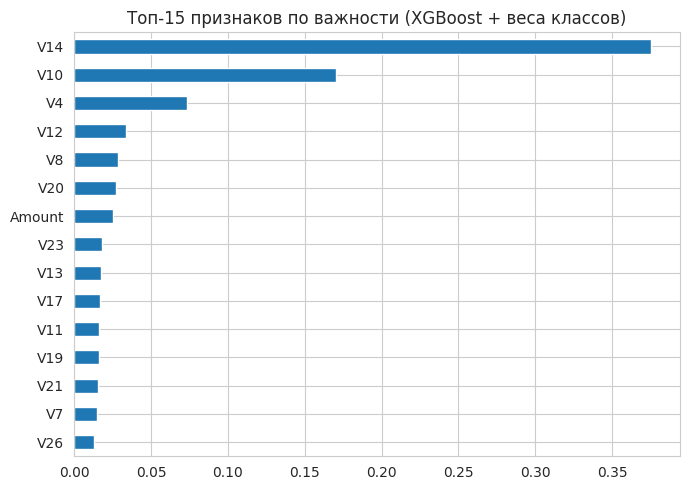

In [17]:
# feature importance
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15).plot(
    kind='barh', figsize=(7,5))
plt.gca().invert_yaxis()
plt.title('Топ-15 признаков по важности (XGBoost + веса классов)')
plt.tight_layout(); plt.show()

**XGBoost + SMOTE**

In [18]:
# SMOTE на train
smote = SMOTE(random_state=RND)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print('До SMOTE :', np.bincount(y_train))
print('После SMOTE:', np.bincount(y_train_sm))

До SMOTE : [226602    378]
После SMOTE: [226602 226602]


In [19]:
xgb_smote = XGBClassifier(
    eval_metric='aucpr', n_estimators=300,
    random_state=RND, n_jobs=-1, tree_method='hist'
)
xgb_smote.fit(X_train_sm, y_train_sm)
proba_sm = xgb_smote.predict_proba(X_test)[:,1]
evaluate('XGBoost (SMOTE)', y_test, proba_sm)
record('XGBoost (SMOTE)', proba_sm)

XGBoost (SMOTE) [threshold=0.500]
PR-AUC:  0.8289   <=== 
ROC-AUC: 0.9553
Precision: 0.7700 | Recall: 0.8105 | F1: 0.7897
Confusion matrix [[TN FP][FN TP]]:
[[56628    23]
 [   18    77]]
Fraud loss: 18


In [20]:
# тюнинг гиперпараметров
param_dist = {
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
    'n_estimators':  [200, 300, 400],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RND)

search = RandomizedSearchCV(
    XGBClassifier(eval_metric='aucpr',
                  random_state=RND, n_jobs=-1, tree_method='hist'),
    param_distributions=param_dist,
    n_iter=10,
    scoring='average_precision',   # = PR-AUC
    cv=cv,
    random_state=RND,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train_sm, y_train_sm)
print('\nЛучшие параметры:', search.best_params_)
print('Лучший CV PR-AUC: %.4f' % search.best_score_)

best_model_sm = search.best_estimator_
proba_best_sm = best_model_sm.predict_proba(X_test)[:,1]
evaluate('XGBoost (SMOTE, после тюнинга)', y_test, proba_best_sm)
record('XGBoost (SMOTE, после тюнинга)', proba_best_sm)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Лучшие параметры: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Лучший CV PR-AUC: 1.0000
XGBoost (SMOTE, после тюнинга) [threshold=0.500]
PR-AUC:  0.8262   <=== 
ROC-AUC: 0.9533
Precision: 0.8000 | Recall: 0.8000 | F1: 0.8000
Confusion matrix [[TN FP][FN TP]]:
[[56632    19]
 [   19    76]]
Fraud loss: 19


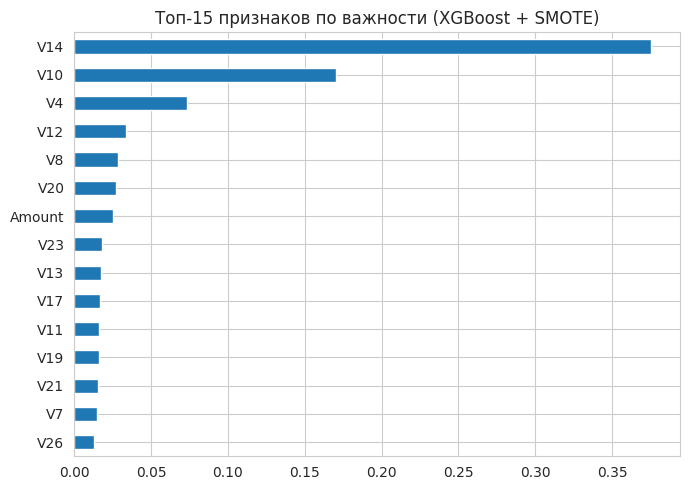

In [21]:
# feature importance
importances = pd.Series(best_model.feature_importances_, index=X_train_sm.columns)
importances.sort_values(ascending=False).head(15).plot(
    kind='barh', figsize=(7,5))
plt.gca().invert_yaxis()
plt.title('Топ-15 признаков по важности (XGBoost + SMOTE)')
plt.tight_layout(); plt.show()

**Сравнение моделей**

In [22]:
comparison = pd.DataFrame(results).set_index('Модель').round(4)
print(comparison.to_string())
print('\nЛучшая по PR-AUC:', comparison['PR-AUC'].idxmax())

                                       PR-AUC  ROC-AUC  Precision  Recall      F1
Модель                                                                           
LogReg (baseline)                      0.7170   0.9666     0.0638  0.8737  0.1190
XGBoost (веса классов)                 0.8210   0.9601     0.8929  0.7895  0.8380
XGBoost (веса классов, после тюнинга)  0.8201   0.9702     0.8352  0.8000  0.8172
XGBoost (SMOTE)                        0.8289   0.9553     0.7700  0.8105  0.7897
XGBoost (SMOTE, после тюнинга)         0.8262   0.9533     0.8000  0.8000  0.8000

Лучшая по PR-AUC: XGBoost (SMOTE)


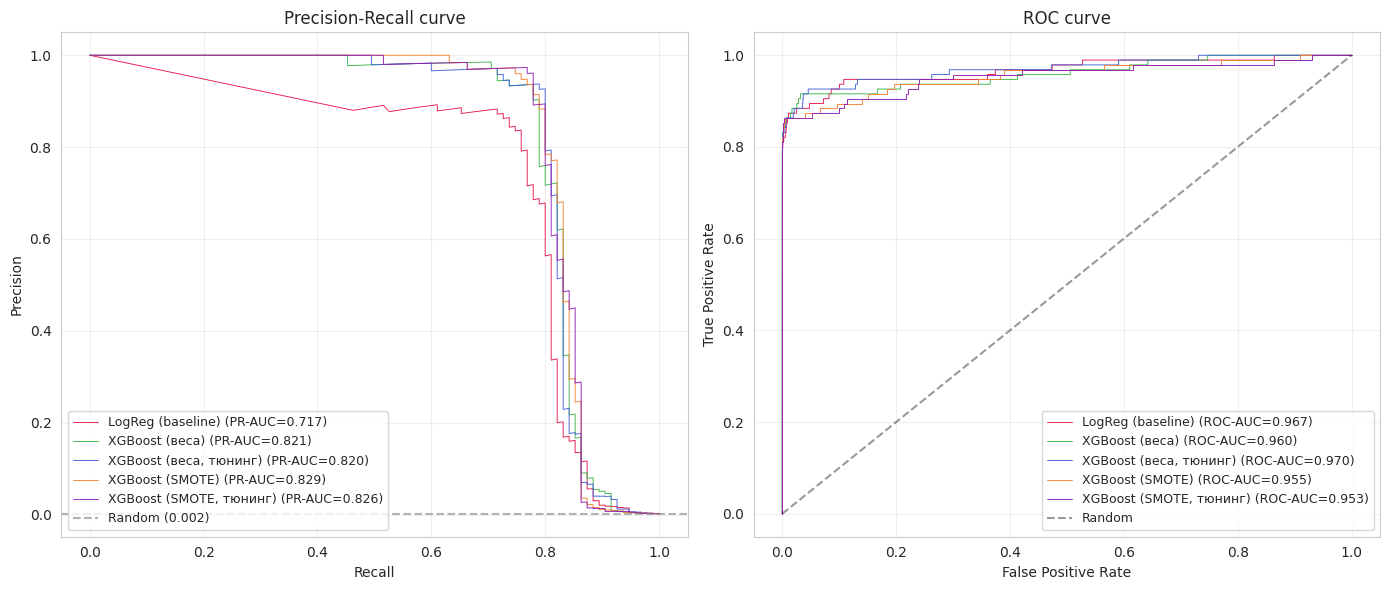

In [23]:
models = [
    (proba_lr,           'LogReg (baseline)'),
    (proba_xgb,          'XGBoost (веса)'),
    (proba_best_xgb,         'XGBoost (веса, тюнинг)'),
    (proba_sm,        'XGBoost (SMOTE)'),
    (proba_best_sm,  'XGBoost (SMOTE, тюнинг)'),
]

colors = ['#E6194B', '#3CB44B', '#4363D8', '#F58231', '#911EB4']

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Precision-Recall
for (proba, name), c in zip(models, colors):
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax[0].plot(r, p, color=c, lw=0.65, label=f'{name} (PR-AUC={ap:.3f})')

baseline_pr = y_test.mean()
ax[0].axhline(baseline_pr, ls='--', color='gray', alpha=0.6,
              label=f'Random ({baseline_pr:.3f})')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall curve')
ax[0].legend(loc='lower left', fontsize=9)
ax[0].grid(alpha=0.3)

# ROC
for (proba, name), c in zip(models, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax[1].plot(fpr, tpr, color=c, lw=0.65, label=f'{name} (ROC-AUC={auc:.3f})')
ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC curve')
ax[1].legend(loc='lower right', fontsize=9)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# финальная модель — лучшая по PR-AUC
proba_final = proba_sm

prec, rec, thr = precision_recall_curve(y_test, proba_final)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = f1[:-1].argmax()
chosen_thr = thr[best_idx]
print(f'Порог по максимуму F1: {chosen_thr:.4f} '
      f'(precision={prec[best_idx]:.3f}, recall={rec[best_idx]:.3f}, F1={f1[best_idx]:.3f})')

Порог по максимуму F1: 0.9708 (precision=0.937, recall=0.779, F1=0.851)


In [41]:
prec, rec, thr = precision_recall_curve(y_test, proba_final)

# таблица precision/recall при разных порогах
print('Порог  | Precision | Recall')
for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    pred = (proba_final >= t).astype(int)
    print(f'{t:.2f}   | {precision_score(y_test, pred):.3f}     | {recall_score(y_test, pred):.3f}')

# порог под целевой recall
target_recall = 0.85 # минимум потерь фрода
mask = rec[:-1] >= target_recall
chosen_thr = thr[mask][-1] if mask.any() else 0.5
print(f'\nВыбранный порог для recall>={target_recall}: {chosen_thr:.4f}\n')

evaluate('XGBoost (SMOTE) & выбранный порог', y_test, proba_final, chosen_thr)

Порог  | Precision | Recall
0.10   | 0.648     | 0.832
0.30   | 0.716     | 0.821
0.50   | 0.770     | 0.811
0.70   | 0.844     | 0.800
0.90   | 0.893     | 0.789

Выбранный порог для recall>=0.85: 0.0042

XGBoost (SMOTE) & выбранный порог [threshold=0.004]
PR-AUC:  0.8289   <=== 
ROC-AUC: 0.9553
Precision: 0.2967 | Recall: 0.8526 | F1: 0.4402
Confusion matrix [[TN FP][FN TP]]:
[[56459   192]
 [   14    81]]
Fraud loss: 14


np.float64(0.8288738737212462)

### Вывод по сравнению

На отложенной выборке лучший PR-AUC показала модель **XGBoost (SMOTE) [threshold=0.500]** (PR-AUC = 0.8289).

- **Веса классов** обычно дают более сбалансированный precision/recall и проще (не меняют размер выборки).
- **SMOTE** часто поднимает recall, но может просаживать precision — модель чаще помечает операции как фрод.

Для дальнейшей работы выбираю **XGBoost (SMOTE)**, потому что в антифроде важнее ловить фрод → recall и SMOTE. Дисбаланс обрабатывается одним способом за раз; балансировка применялась только к train.